In [2]:
import pandas as pd
import numpy as np

In [ ]:
import bql
from functools import reduce

bq = bql.Service()
sea_countries = ['ID', 'MY', 'PH', 'SG', 'TH']

raw_univ = bq.univ.bondsuniv(types='active')

univ_sovereign = bq.univ.filter(
    raw_univ,
    bq.func.and_(
        bq.func.in_(bq.data.cntry_of_risk(), sea_countries),
        bq.data.bics_level_2_industry_group_name() == 'Sovereigns'
    )
)

univ_quasi = bq.univ.filter(
    raw_univ,
    bq.func.and_(
        bq.func.in_(bq.data.cntry_of_risk(), sea_countries),
        bq.func.or_(
            bq.data.classification_name('BCLASS', '4') == 'Government Owned, No Guarantee',
            bq.data.classification_name('BCLASS', '4') == 'Government Guaranteed'
        )
    )
)

univ_corp = bq.univ.filter(
    raw_univ,
    bq.func.and_(
        bq.func.in_(bq.data.cntry_of_risk(), sea_countries),
        bq.data.market_sector_des() == 'Corp',
        bq.func.not_(
            bq.func.or_(
                bq.data.classification_name('BCLASS', '4') == 'Government Owned, No Guarantee',
                bq.data.classification_name('BCLASS', '4') == 'Government Guaranteed'
            )
        )
    )
)

In [2]:
def get_universe_ids(univ):
    field = bq.data.id()
    request = bql.Request(univ, field)
    response = bq.execute(request)
    df = response[0].df()
    return df.index.tolist()

sov_ids = get_universe_ids(univ_sovereign)
quasi_ids = get_universe_ids(univ_quasi)
corp_ids = get_universe_ids(univ_corp)

print(f"Sovereign: {len(sov_ids)} bonds")
print(f"Quasi-Sovereign: {len(quasi_ids)} bonds")
print(f"Corp: {len(corp_ids)} bonds")

all_ids = sov_ids + quasi_ids + corp_ids
print(f"Total bonds: {len(all_ids)}")

Sovereign: 1011 bonds
Quasi-Sovereign: 2398 bonds
Corp: 10406 bonds
Total bonds: 13815


In [3]:
def pull_static_fields(ids, chunk_size=200, rating_source='SP'):
    fields_static = {
        'issue_dt': bq.data.issue_dt(),
        'maturity': bq.data.maturity(),
        'currency': bq.data.crncy(),
        'rating': bq.data.rating(rating_source=rating_source, rating_horizon='LT')['value']
    }
    chunks = [ids[i:i+chunk_size] for i in range(0, len(ids), chunk_size)]
    static_dfs = []
    for i, chunk in enumerate(chunks):
        try:
            request = bql.Request(chunk, fields_static)
            response = bq.execute(request)
            dfs = [r.df() for r in response]
            combined = pd.concat(dfs, axis=1)
            combined = combined.loc[:, ~combined.columns.duplicated()]
            static_dfs.append(combined)
            print(f"Static fields chunk {i+1}/{len(chunks)} done")
        except Exception as e:
            print(f"Static fields chunk {i+1}/{len(chunks)} FAILED - {e}")
    return pd.concat(static_dfs, axis=0) if static_dfs else pd.DataFrame()

bond_static = pull_static_fields(all_ids, rating_source='SP')

today = pd.Timestamp.today().normalize()
bond_static['maturity'] = pd.to_datetime(bond_static['maturity'], errors='coerce')
bond_static['issue_dt'] = pd.to_datetime(bond_static['issue_dt'], errors='coerce')
bond_static['end_date'] = bond_static['maturity'].apply(lambda x: min(x, today) if pd.notna(x) else today)
bond_static['start_date'] = bond_static['issue_dt']

print(f"Static fields pulled: {len(bond_static)}")
print(f"Rating non-null %: {bond_static['rating'].notna().mean()*100:.1f}%")

Static fields chunk 1/70 done
Static fields chunk 2/70 done
Static fields chunk 3/70 done
Static fields chunk 4/70 done
Static fields chunk 5/70 done
Static fields chunk 6/70 done
Static fields chunk 7/70 done
Static fields chunk 8/70 done
Static fields chunk 9/70 done
Static fields chunk 10/70 done
Static fields chunk 11/70 done
Static fields chunk 12/70 done
Static fields chunk 13/70 done
Static fields chunk 14/70 done
Static fields chunk 15/70 done
Static fields chunk 16/70 done
Static fields chunk 17/70 done
Static fields chunk 18/70 done
Static fields chunk 19/70 done
Static fields chunk 20/70 done
Static fields chunk 21/70 done
Static fields chunk 22/70 done
Static fields chunk 23/70 done
Static fields chunk 24/70 done
Static fields chunk 25/70 done
Static fields chunk 26/70 done
Static fields chunk 27/70 done
Static fields chunk 28/70 done
Static fields chunk 29/70 done
Static fields chunk 30/70 done
Static fields chunk 31/70 done
Static fields chunk 32/70 done
Static fields chu

In [4]:
def pull_historical_yield(ids, category, chunk_size=200, date_range='-1Y'):
    all_dfs = []
    chunks = [ids[i:i+chunk_size] for i in range(0, len(ids), chunk_size)]
    for i, chunk in enumerate(chunks):
        try:
            fields = {
                'yield_bid': bq.data.yld_annual_bid(dates=bq.func.range(date_range, '0D'), fill='prev'),
                'yield_ask': bq.data.yld_annual_ask(dates=bq.func.range(date_range, '0D'), fill='prev')
            }
            request = bql.Request(chunk, fields)
            response = bq.execute(request)
            dfs = [r.df().reset_index() for r in response]
            combined = reduce(lambda l, r: pd.merge(l, r, on=['ID', 'DATE'], how='outer'), dfs)
            combined['category'] = category
            all_dfs.append(combined)
            print(f"{category} chunk {i+1}/{len(chunks)} done: {len(combined)} rows")
        except Exception as e:
            print(f"{category} chunk {i+1}/{len(chunks)} FAILED - {e}")
    return pd.concat(all_dfs, axis=0) if all_dfs else pd.DataFrame()

sov_hist = pull_historical_yield(sov_ids, 'Sovereign')
quasi_hist = pull_historical_yield(quasi_ids, 'Quasi-Sovereign')
corp_hist = pull_historical_yield(corp_ids, 'Corp')

big_hist_df = pd.concat([sov_hist, quasi_hist, corp_hist], axis=0)
big_hist_df = big_hist_df.reset_index(drop=True)

big_hist_df = big_hist_df.merge(
    bond_static[['start_date', 'end_date', 'currency', 'rating']],
    left_on='ID', right_index=True, how='left'
)

big_hist_df = big_hist_df[
    (big_hist_df['DATE'] >= big_hist_df['start_date']) &
    (big_hist_df['DATE'] <= big_hist_df['end_date'])
]
big_hist_df = big_hist_df.reset_index(drop=True)

print(f"\nTotal rows: {len(big_hist_df)}")
print(f"Yield_bid non-null %: {big_hist_df['yield_bid'].notna().mean()*100:.1f}%")
print(f"Rating non-null %: {big_hist_df['rating'].notna().mean()*100:.1f}%")

Sovereign chunk 1/6 done: 73200 rows
Sovereign chunk 2/6 done: 71740 rows
Sovereign chunk 3/6 done: 72470 rows
Sovereign chunk 4/6 done: 72470 rows
Sovereign chunk 5/6 done: 72835 rows
Sovereign chunk 6/6 done: 4026 rows
Quasi-Sovereign chunk 1/12 done: 69185 rows
Quasi-Sovereign chunk 2/12 done: 67725 rows
Quasi-Sovereign chunk 3/12 done: 73200 rows
Quasi-Sovereign chunk 4/12 done: 71740 rows
Quasi-Sovereign chunk 5/12 done: 66630 rows
Quasi-Sovereign chunk 6/12 done: 65170 rows
Quasi-Sovereign chunk 7/12 done: 67360 rows
Quasi-Sovereign chunk 8/12 done: 67725 rows
Quasi-Sovereign chunk 9/12 done: 67725 rows
Quasi-Sovereign chunk 10/12 done: 68455 rows
Quasi-Sovereign chunk 11/12 done: 66995 rows
Quasi-Sovereign chunk 12/12 done: 70278 rows
Corp chunk 1/53 done: 68455 rows
Corp chunk 2/53 done: 57870 rows
Corp chunk 3/53 done: 56775 rows
Corp chunk 4/53 done: 48015 rows
Corp chunk 5/53 done: 52395 rows
Corp chunk 6/53 done: 62250 rows
Corp chunk 7/53 done: 61155 rows
Corp chunk 8/53 d

In [5]:
snapshot_date = big_hist_df['DATE'].max()
snapshot = big_hist_df[big_hist_df['DATE'] == snapshot_date].copy()
snapshot = snapshot.reset_index(drop=True)
snapshot = snapshot.dropna(subset=['yield_bid', 'yield_ask'])

sane_mask = (snapshot['yield_bid'].abs() < 100) & (snapshot['yield_ask'].abs() < 100)
snapshot_clean = snapshot[sane_mask].copy().reset_index(drop=True)

snapshot_clean['bid_ask_spread'] = snapshot_clean['yield_ask'] - snapshot_clean['yield_bid']
snapshot_clean['years_to_maturity'] = (snapshot_clean['end_date'] - snapshot_clean['DATE']).dt.days / 365.25

rating_scale = {
    'AAA': 1, 'AA+': 2, 'AA': 3, 'AA-': 4,
    'A+': 5, 'A': 6, 'A-': 7,
    'BBB+': 8, 'BBB': 9, 'BBB-': 10,
    'BB+': 11, 'BB': 12, 'BB-': 13,
    'B+': 14, 'B': 15, 'B-': 16,
    'CCC+': 17, 'CCC': 18, 'CCC-': 19,
    'CC': 20, 'C': 21, 'D': 22,
    'NR': np.nan, 'N.A.': np.nan
}

snapshot_clean['rating_numeric'] = snapshot_clean['rating'].map(rating_scale)
print(f"Rating mapped non-null: {snapshot_clean['rating_numeric'].notna().sum()}/{len(snapshot_clean)}")

snapshot_clean = snapshot_clean.dropna(subset=['yield_bid', 'bid_ask_spread', 'years_to_maturity', 'rating_numeric'])
snapshot_clean = snapshot_clean.reset_index(drop=True)

features_extended = snapshot_clean[['yield_bid', 'bid_ask_spread', 'years_to_maturity', 'rating_numeric']]
print(f"Clean snapshot for PCA: {len(snapshot_clean)} bonds")

Rating mapped non-null: 402/5425
Clean snapshot for PCA: 402 bonds


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if 'features_extended' not in globals() or features_extended.empty:
    features_extended = pd.read_csv('features_extended.csv')

X = StandardScaler().fit_transform(features_extended)
pca = PCA(n_components=4)
pca.fit(X)
pca_scores = pca.transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_.T,
    index=features_extended.columns,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
print("\nLoadings:")
print(loadings)

if 'snapshot_clean' in globals() and not snapshot_clean.empty:
    plot_df = snapshot_clean.copy()
else:
    plot_df = pd.read_csv('plot_df.csv')

plot_df['PC1'] = pca_scores[:, 0]
plot_df['PC2'] = pca_scores[:, 1]
plot_df['PC3'] = pca_scores[:, 2]
plot_df['PC4'] = pca_scores[:, 3]

Explained variance ratio: [0.44750764 0.33122415 0.22126821 0.        ]

Loadings:
                        PC1       PC2       PC3  PC4
yield_bid          0.697804  0.131535 -0.704108  0.0
bid_ask_spread    -0.141471  0.988940  0.044540  0.0
years_to_maturity -0.000000  0.000000 -0.000000  1.0
rating_numeric     0.702179  0.068531  0.708694  0.0


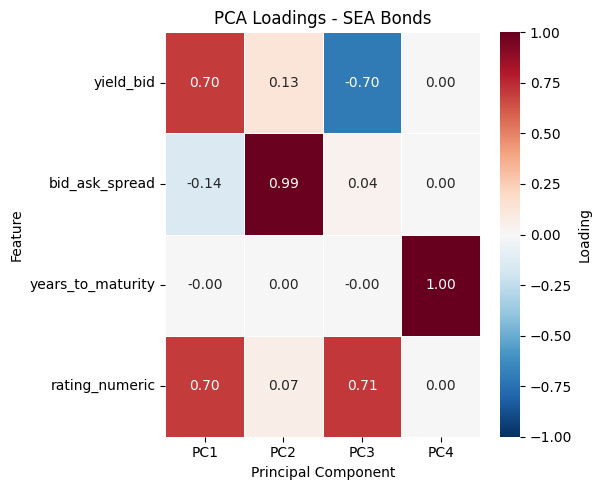

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Loading'}
)
plt.title('PCA Loadings - SEA Bonds')
plt.ylabel('Feature')
plt.xlabel('Principal Component')
plt.tight_layout()
plt.show()